In [1]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import pickle

In [2]:
df = pd.read_csv('../data_folder/Bitcoin_history_data.csv')
df.head()

,Date,Close,High,Low,Open,Volume
0,2015-01-01,314.248993,320.434998,314.002991,320.434998,8036550
1,2015-01-02,315.032013,315.838989,313.565002,314.079010,7860650
2,2015-01-03,281.082001,315.149994,281.082001,314.846008,33054400
3,2015-01-04,264.195007,287.230011,257.612000,281.145996,55629100
4,2015-01-05,274.473999,278.341003,265.084015,265.084015,43962800


## Créer la target (prix monte dans 5 jours)


In [3]:
df["future_close"] = df["Close"].shift(-5)
df["target"] = (df["future_close"] > df["Close"]).astype(int)
df = df.dropna()

## Sélection des features

In [4]:
features = ["Open", "High", "Low", "Close", "Volume"]

X = df[features]
y = df["target"]


## Split temporel 

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

## Standardisation

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
model = LogisticRegression()

In [8]:
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

## Evaluation

In [9]:
from sklearn.metrics import accuracy_score

predictions = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.47990255785627284


In [10]:
# Export the pipeline as a pickle file
with open('../models/linear_regression_1.pkl', 'wb') as file:
    pickle.dump(model, file)

In [11]:
# Load the pipeline
with open('../models/linear_regression_1.pkl', 'rb') as file:
    model = pickle.load(file)

In [12]:
from app.ai_for_finance import my_prediction_function

my_prediction_function(
    0,0,0,0,0
)

ModuleNotFoundError: No module named 'app'

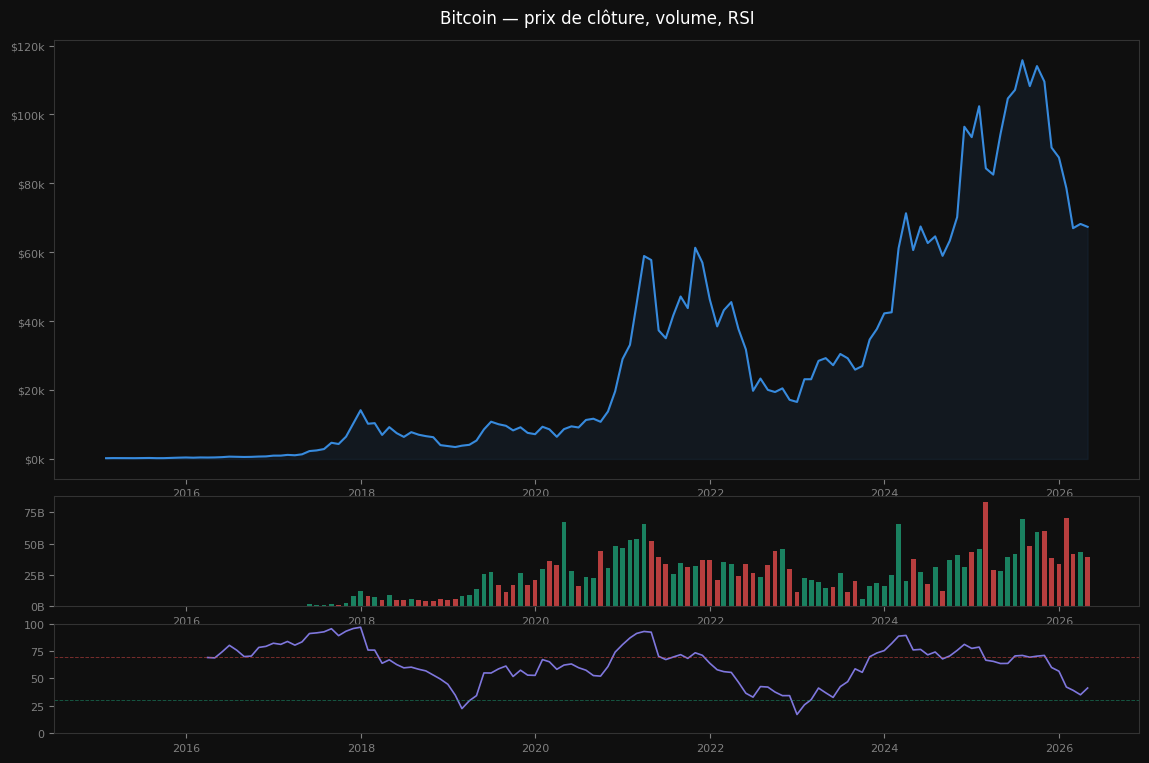

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np

df2 = pd.read_csv('../data_folder/Bitcoin_history_data.csv')
df2.columns = df2.columns.str.strip()
df2['Date'] = pd.to_datetime(df2['Date'])
df2 = df2.resample('ME', on='Date').last()

colors = ['#1D9E75' if df2['Close'].iloc[i] >= df2['Close'].iloc[i-1] else '#E24B4A'
          for i in range(len(df2))]

fig = plt.figure(figsize=(14, 9), facecolor='#0f0f0f')
gs = gridspec.GridSpec(3, 1, height_ratios=[4, 1, 1], hspace=0.08)

ax1 = fig.add_subplot(gs[0])
ax1.plot(df2.index, df2['Close'], color='#378ADD', linewidth=1.5)
ax1.fill_between(df2.index, df2['Close'], alpha=0.08, color='#378ADD')
ax1.set_facecolor('#0f0f0f')
ax1.tick_params(colors='gray', labelsize=8)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax1.set_title('Bitcoin — prix de clôture, volume, RSI', color='white', fontsize=12, pad=12)
for spine in ax1.spines.values(): spine.set_color('#333')

ax2 = fig.add_subplot(gs[1], sharex=ax1)
ax2.bar(df2.index, df2['Volume'], color=colors, width=20, alpha=0.8)
ax2.set_facecolor('#0f0f0f')
ax2.tick_params(colors='gray', labelsize=8)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e9:.0f}B'))
for spine in ax2.spines.values(): spine.set_color('#333')

delta = df2['Close'].diff()
gain = delta.clip(lower=0).rolling(14).mean()
loss = -delta.clip(upper=0).rolling(14).mean()
rsi = 100 - (100 / (1 + gain/loss))

ax3 = fig.add_subplot(gs[2], sharex=ax1)
ax3.plot(df2.index, rsi, color='#7F77DD', linewidth=1.2)
ax3.axhline(70, color='#E24B4A', linewidth=0.7, linestyle='--', alpha=0.5)
ax3.axhline(30, color='#1D9E75', linewidth=0.7, linestyle='--', alpha=0.5)
ax3.set_ylim(0, 100)
ax3.set_facecolor('#0f0f0f')
ax3.tick_params(colors='gray', labelsize=8)
for spine in ax3.spines.values(): spine.set_color('#333')

plt.savefig('btc_dashboard.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

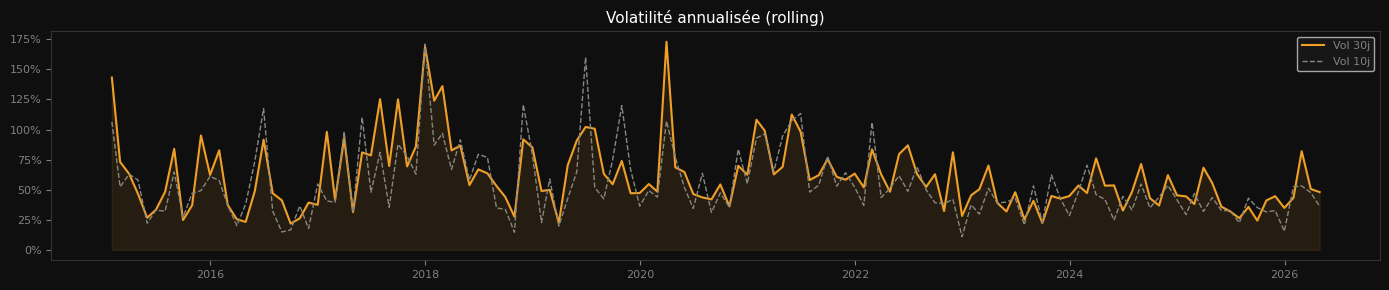

In [ ]:
# Volatilité rolling (écart-type des rendements journaliers, annualisé)
df2_daily = pd.read_csv('../data_folder/Bitcoin_history_data.csv')
df2_daily.columns = df2_daily.columns.str.strip()
df2_daily['Date'] = pd.to_datetime(df2_daily['Date'])
df2_daily = df2_daily.set_index('Date')

df2_daily['return_1d'] = df2_daily['Close'].pct_change()
df2_daily['vol_30d'] = df2_daily['return_1d'].rolling(30).std() * np.sqrt(365) * 100
df2_daily['vol_10d'] = df2_daily['return_1d'].rolling(10).std() * np.sqrt(365) * 100

vol_monthly = df2_daily[['vol_30d', 'vol_10d']].resample('ME').last()

fig, ax = plt.subplots(figsize=(14, 3), facecolor='#0f0f0f')
ax.plot(vol_monthly.index, vol_monthly['vol_30d'], color='#EF9F27', linewidth=1.5, label='Vol 30j')
ax.plot(vol_monthly.index, vol_monthly['vol_10d'], color='#888780', linewidth=1, linestyle='--', label='Vol 10j')
ax.fill_between(vol_monthly.index, vol_monthly['vol_30d'], alpha=0.1, color='#EF9F27')
ax.set_facecolor('#0f0f0f')
ax.tick_params(colors='gray', labelsize=8)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.legend(facecolor='#1a1a1a', labelcolor='gray', fontsize=8)
ax.set_title('Volatilité annualisée (rolling)', color='white', fontsize=11)
for spine in ax.spines.values(): spine.set_color('#333')
plt.tight_layout()
plt.show()

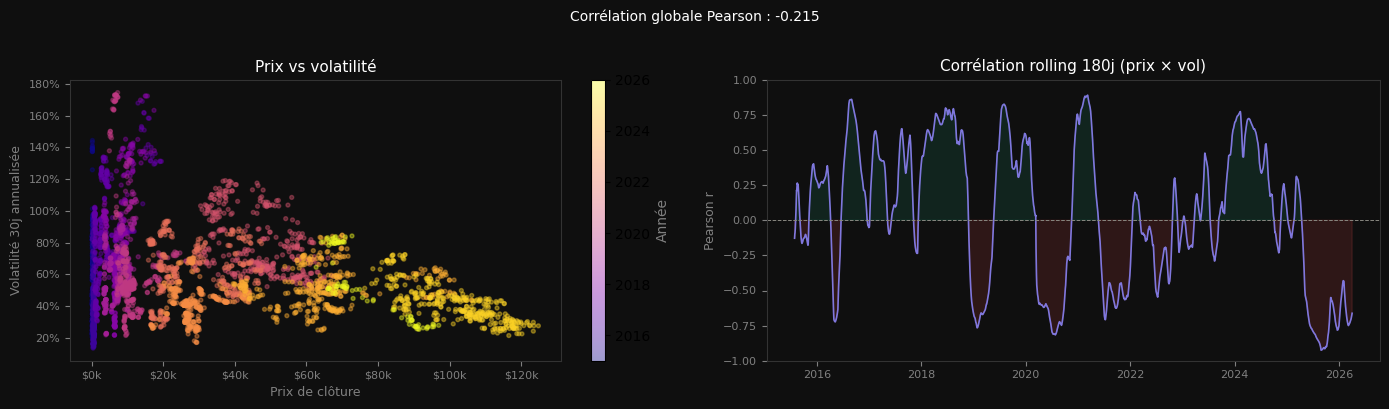

Corrélation globale : -0.215


In [ ]:
# Corrélation prix vs volatilité
merged = df2_daily[['Close', 'vol_30d']].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4), facecolor='#0f0f0f')

# Scatter prix vs vol
ax = axes[0]
sc = ax.scatter(merged['Close'], merged['vol_30d'],
                c=merged.index.year, cmap='plasma',
                alpha=0.4, s=8)
ax.set_facecolor('#0f0f0f')
ax.tick_params(colors='gray', labelsize=8)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.set_xlabel('Prix de clôture', color='gray', fontsize=9)
ax.set_ylabel('Volatilité 30j annualisée', color='gray', fontsize=9)
ax.set_title('Prix vs volatilité', color='white', fontsize=11)
for spine in ax.spines.values(): spine.set_color('#333')
plt.colorbar(sc, ax=ax, label='Année').ax.yaxis.label.set_color('gray')

# Corrélation rolling dans le temps
corr_rolling = merged['Close'].rolling(180).corr(merged['vol_30d'])

ax2 = axes[1]
ax2.plot(corr_rolling.index, corr_rolling, color='#7F77DD', linewidth=1.2)
ax2.axhline(0, color='#888780', linewidth=0.7, linestyle='--')
ax2.fill_between(corr_rolling.index, corr_rolling, 0,
                 where=corr_rolling > 0, alpha=0.15, color='#1D9E75')
ax2.fill_between(corr_rolling.index, corr_rolling, 0,
                 where=corr_rolling < 0, alpha=0.15, color='#E24B4A')
ax2.set_ylim(-1, 1)
ax2.set_facecolor('#0f0f0f')
ax2.tick_params(colors='gray', labelsize=8)
ax2.set_title('Corrélation rolling 180j (prix × vol)', color='white', fontsize=11)
ax2.set_ylabel('Pearson r', color='gray', fontsize=9)
for spine in ax2.spines.values(): spine.set_color('#333')

corr_global = merged['Close'].corr(merged['vol_30d'])
fig.suptitle(f'Corrélation globale Pearson : {corr_global:.3f}',
             color='white', fontsize=10, y=1.01)

plt.tight_layout()
plt.show()
print(f"Corrélation globale : {corr_global:.3f}")

In [ ]:
from app.ml_logic.data import get_financial_data

data = get_financial_data(
    tickers=['BTC-USD', 'ETH-USD', 'SPY'],
    period_years=10
)

df_btc = data['BTC-USD']
df_btc.head()